In [2]:
# Si besoin seulement
# !pip install networkx matplotlib kagglehub pandas


In [3]:
import kagglehub
from pathlib import Path

# Télécharger la dernière version du dataset
path = kagglehub.dataset_download("mateuscco/toy-network-datasets")
print("Path to dataset files:", path)

data_dir = Path(path)

# Lister tous les fichiers .net disponibles
net_files = sorted(data_dir.rglob("*.net"))
print(f"{len(net_files)} fichiers .net trouvés:")
for f in net_files:
    print("-", f.name)


100%|██████████| 68.7k/68.7k [00:00<00:00, 689kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mateuscco/toy-network-datasets/versions/1
5 fichiers .net trouvés:
- 26KeroNetwork.net
- NetScience.net
- Ring25.net
- YeastS.net
- imports_manufactures.net


In [4]:
import networkx as nx

# Choisir le fichier .net à analyser :
# 1) si 'karate.net' existe on le prend, sinon
# 2) on prend le premier .net trouvé
candidate = next((f for f in net_files if f.name.lower() == "karate.net"), None)
pajek_path = candidate if candidate is not None else (net_files[0] if net_files else None)
assert pajek_path is not None, "Aucun fichier .net trouvé dans le dataset !"

print("Graphe choisi :", pajek_path.name)

# Charger le .net
G_loaded = nx.read_pajek(str(pajek_path))
# Convertir en graphe simple non orienté (souvent utile avec les .net)
G = nx.Graph(G_loaded)


Graphe choisi : 26KeroNetwork.net


In [5]:
print("Nombre de nœuds :", G.number_of_nodes())
print("Nombre d’arêtes :", G.number_of_edges())


Nombre de nœuds : 135
Nombre d’arêtes : 318


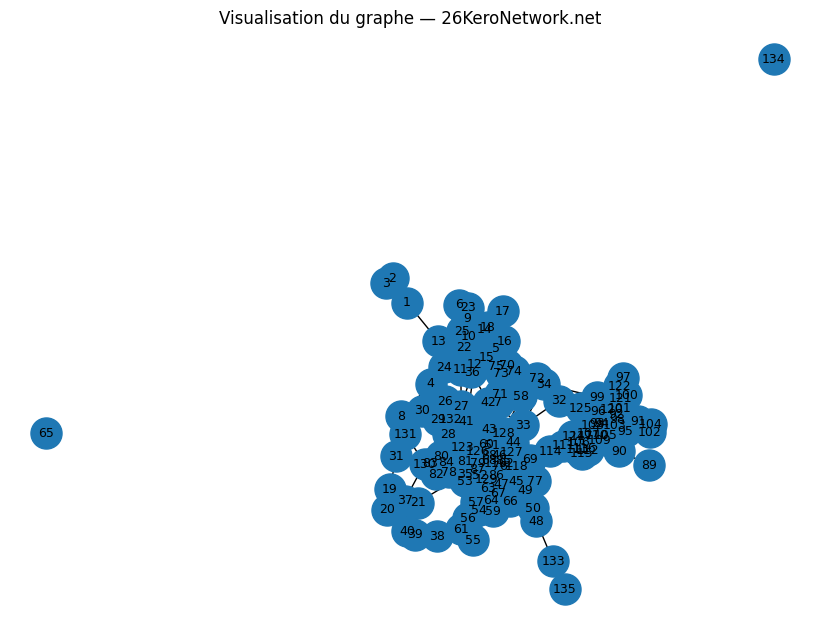

In [6]:
import matplotlib.pyplot as plt

# Mise en page stable
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(8, 6))
nx.draw(G, pos=pos, with_labels=True, node_size=500, font_size=9)
plt.title(f"Visualisation du graphe — {pajek_path.name}")
plt.show()


In [7]:
import pandas as pd

degrees = dict(G.degree())
deg_df = (
    pd.DataFrame({"node": list(degrees.keys()), "degree": list(degrees.values())})
    .sort_values("degree", ascending=False)
    .reset_index(drop=True)
)
deg_df.head(10)  # aperçu


,node,degree
0,12,12
1,99,11
2,81,11
3,85,11
4,103,11
5,86,10
6,93,9
7,106,9
8,47,9
9,41,8


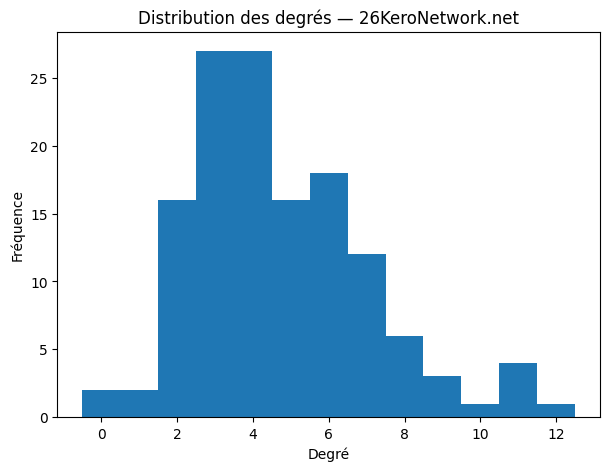

In [8]:
vals = deg_df["degree"].tolist()
plt.figure(figsize=(7, 5))
plt.hist(vals, bins=range(min(vals), max(vals) + 2), align="left")
plt.xlabel("Degré")
plt.ylabel("Fréquence")
plt.title(f"Distribution des degrés — {pajek_path.name}")
plt.show()
